<a href="https://colab.research.google.com/github/CarloR04/Challenge-Telcom_X_2/blob/main/Telcom_X_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CHALLENGE TELCOM X PARTE 2**

🎯 **Misión**

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

## 🛠️ **PREPARACIÓN DE LOS DATOS**

### **Extracción del Archivo Tratado**

Del anterior Challenge (Parte 1) se tiene dos archicos CSV que se usaran como archivos tratados:

1. **Data.csv:** Contiene todas las columnas con la signularidad de que los datos contienen strings en las respuesta binaria (SI Y NO).
2. **Data_binaria.csv:** Los datos tiene tratamiento Binario pasando los strings a (0 Y 1).

In [2]:
import pandas as pd

In [3]:
Data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/ALURA/Challenge Telcom_X/PARTE 2/Data.csv')
Data_binaria = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/ALURA/Challenge Telcom_X/PARTE 2/Data_binaria.csv')

In [4]:
Data.head()

,ID_cliente,Permanencia,Genero_cliente,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Internet,...,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Tipo_Contrato,Preferencia_Factura,Metodo_de_Pago,Gasto_Mensual,Gasto_Total,Cuentas_Diarias
0,0002-ORFBO,no,female,0,yes,yes,9,yes,no,dsl,...,no,yes,yes,no,one year,yes,mailed check,65.6,593.30,2.19
1,0003-MKNFE,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40,2.00
2,0004-TLHLJ,yes,male,0,no,no,4,yes,no,fiber optic,...,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85,2.46
3,0011-IGKFF,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40,2.80


In [5]:
Data_binaria.head()

,ID_cliente,Permanencia,Genero_cliente,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Internet,...,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Tipo_Contrato,Preferencia_Factura,Metodo_de_Pago,Gasto_Mensual,Gasto_Total,Cuentas_Diarias
0,0002-ORFBO,0,female,0,1,1,9,1,0,dsl,...,0,1,1,0,one year,1,mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,male,0,0,0,9,1,1,dsl,...,0,0,0,1,month-to-month,0,mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,male,0,0,0,4,1,0,fiber optic,...,1,0,0,0,month-to-month,1,electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,male,1,1,0,13,1,0,fiber optic,...,1,0,1,1,month-to-month,1,electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,female,1,1,0,3,1,0,fiber optic,...,0,1,1,0,month-to-month,1,mailed check,83.9,267.40,2.80


### **Eliminación de Columnas Irrelevantes**

Trabajaremos con el csv Binario por facilidad númerica y estadistica necesaria de los datos

In [6]:
df = Data_binaria.copy()
columns_to_drop = ['ID_cliente'] #Elimanos la columna
df = df.drop(columns=columns_to_drop)

df.head()

,Permanencia,Genero_cliente,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Internet,Sus_Seguridad_online,...,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Tipo_Contrato,Preferencia_Factura,Metodo_de_Pago,Gasto_Mensual,Gasto_Total,Cuentas_Diarias
0,0,female,0,1,1,9,1,0,dsl,0,...,0,1,1,0,one year,1,mailed check,65.6,593.30,2.19
1,0,male,0,0,0,9,1,1,dsl,0,...,0,0,0,1,month-to-month,0,mailed check,59.9,542.40,2.00
2,1,male,0,0,0,4,1,0,fiber optic,0,...,1,0,0,0,month-to-month,1,electronic check,73.9,280.85,2.46
3,1,male,1,1,0,13,1,0,fiber optic,0,...,1,0,1,1,month-to-month,1,electronic check,98.0,1237.85,3.27
4,1,female,1,1,0,3,1,0,fiber optic,0,...,0,1,1,0,month-to-month,1,mailed check,83.9,267.40,2.80


### **Encoding**

In [7]:
df_encoding = df.copy()
df_encoding= pd.get_dummies(df, columns=['Genero_cliente', 'Sus_Internet', 'Tipo_Contrato', 'Metodo_de_Pago'])
pd.set_option('display.max_columns', None)
df_encoding.head()

,Permanencia,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Genero_cliente_female,Genero_cliente_male,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check
0,0,0,1,1,9,1,0,0,1,0,1,1,0,1,65.6,593.30,2.19,True,False,True,False,False,False,True,False,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,0,0,1,0,59.9,542.40,2.00,False,True,True,False,False,True,False,False,False,False,False,True
2,1,0,0,0,4,1,0,0,0,1,0,0,0,1,73.9,280.85,2.46,False,True,False,True,False,True,False,False,False,False,True,False
3,1,1,1,0,13,1,0,0,1,1,0,1,1,1,98.0,1237.85,3.27,False,True,False,True,False,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0,0,0,0,1,1,0,1,83.9,267.40,2.80,True,False,False,True,False,True,False,False,False,False,False,True


Las columnas 'Genero_cliente', 'Sus_Internet', 'Tipo_Contrato' y 'Metodo_de_Pago' fueron seleccionadas porque son columnas categóricas de tipo nominal. Esto significa que sus valores son etiquetas o nombres que representan categorías distintas, sin un orden intrínseco entre ellas.

El 'one-hot encoding' resuelve esto creando nuevas columnas binarias (0 o 1) para cada categoría única en la columna original


### **Verificación de la Proporción de Cancelación (Churn)**

In [8]:
churn_proportion = df_encoding['Permanencia'].value_counts(normalize=True)
print("Proporción de clientes por estado de permanencia:")
print(churn_proportion * 100)

Proporción de clientes por estado de permanencia:
Permanencia
0             71.198569
1             25.719004
no reporta     3.082427
Name: proportion, dtype: float64


### Balanceo de Clases

Eliminar las filas donde 'Permanencia' es 'no reporta' del conjunto de datos, ya que no representan un estado claro de cancelación para el modelado.


In [9]:
print(f"Shape before filtering: {df_encoding.shape}")
df_encoding = df_encoding[df_encoding['Permanencia'] != 'no reporta']
print(f"Shape after filtering: {df_encoding.shape}")
df_encoding.head()

Shape before filtering: (7267, 29)
Shape after filtering: (7043, 29)


,Permanencia,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Genero_cliente_female,Genero_cliente_male,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check
0,0,0,1,1,9,1,0,0,1,0,1,1,0,1,65.6,593.30,2.19,True,False,True,False,False,False,True,False,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,0,0,1,0,59.9,542.40,2.00,False,True,True,False,False,True,False,False,False,False,False,True
2,1,0,0,0,4,1,0,0,0,1,0,0,0,1,73.9,280.85,2.46,False,True,False,True,False,True,False,False,False,False,True,False
3,1,1,1,0,13,1,0,0,1,1,0,1,1,1,98.0,1237.85,3.27,False,True,False,True,False,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0,0,0,0,1,1,0,1,83.9,267.40,2.80,True,False,False,True,False,True,False,False,False,False,False,True


In [14]:
X = df_encoding.drop('Permanencia', axis=1)
y = df_encoding['Permanencia'].astype(int)

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
   Cliente_Tercera_Edad  Pareja_Cliente  Dependientes_del_Cliente  \
0                     0               1                         1   
1                     0               0                         0   
2                     0               0                         0   
3                     1               1                         0   
4                     1               1                         0   

   Meses_del_Contrato  Servicio_telefonico  Multiples_lineas_telefonicas  \
0                   9                    1                             0   
1                   9                    1                             1   
2                   4                    1                             0   
3                  13                    1                             0   
4                   3                    1                             0   

   Sus_Seguridad_online  Sus_Respaldo_online  Sus_Protección_al_Dispositivo  \
0                     0       

Ahora que las características (X) y el objetivo (y) se han separado y la variable objetivo es numérica, aplicaré la técnica SMOTE para equilibrar las clases en la variable objetivo. Esto implica importar SMOTE, instanciarlo y, a continuación, remuestrear los datos.


El DataFrame contiene valores NaN. Necesito identificar y gestionar estos valores faltantes antes de aplicar SMOTE. Comprobaré si hay valores NaN en y luego los imputaré utilizando la estrategia de media para asegurar que no contenga NaN, lo cual es un requisito previo para SMOTE.

In [17]:
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
import numpy as np

# Comprobar valores NaN
print("Valores NaN antes de la imputación:")
print(X.isnull().sum()[X.isnull().sum() > 0])

# Imputar valores NaN en el df utilizando la estrategia de media
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Verificar que no haya más valores NaN
print("\nValores NaN después de la imputación:")
print(X_imputed.isnull().sum()[X_imputed.isnull().sum() > 0])

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

print("\nProporción de clientes por estado de permanencia después de SMOTE:")
print(y_resampled.value_counts(normalize=True) * 100)

Valores NaN antes de la imputación:
Gasto_Total    11
dtype: int64

Valores NaN después de la imputación:
Series([], dtype: int64)

Proporción de clientes por estado de permanencia después de SMOTE:
Permanencia
0    50.0
1    50.0
Name: proportion, dtype: float64


- El conjunto de datos df_encoding contenía 7267 filas. Tras filtrar las filas donde "Permanencia" era "no reporta", se eliminaron 224 filas, reduciendo el conjunto de datos a 7043.

- Se identificó que la columna "Gasto_Total" tenía 11 valores faltantes (NaN), que posteriormente se imputaron mediante la estrategia de media.

- Tras aplicar la técnica SMOTE, la variable objetivo "Permanencia" alcanzó una distribución de clases perfectamente equilibrada, donde ambas clases (0 y 1) representan el 50% del conjunto de datos.

### Normalización o Estandarización

Identificar las columnas de tipo numérico en `X_resampled` que requieren estandarización.


In [21]:
numerical_cols = ['Meses_del_Contrato', 'Gasto_Mensual', 'Gasto_Total', 'Cuentas_Diarias']
print(f"Columnas numéricas identificadas para estandarización: {numerical_cols}")

Columnas numéricas identificadas para estandarización: ['Meses_del_Contrato', 'Gasto_Mensual', 'Gasto_Total', 'Cuentas_Diarias']


Aplicar `StandardScaler` de `sklearn.preprocessing` a las columnas numéricas identificadas


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_resampled[numerical_cols] = scaler.fit_transform(X_resampled[numerical_cols])

Para verificar la estandarización, mostraré las estadísticas descriptivas (media y desviación estándar) de las características numéricas escaladas en X_resampled.

In [24]:
print("Estadísticas descriptivas de características numéricas escaladas:")
print(X_resampled[numerical_cols].describe().loc[['mean', 'std']])

Estadísticas descriptivas de características numéricas escaladas:
      Meses_del_Contrato  Gasto_Mensual   Gasto_Total  Cuentas_Diarias
mean       -1.098636e-17   3.295908e-17 -1.098636e-17     3.295908e-17
std         1.000048e+00   1.000048e+00  1.000048e+00     1.000048e+00


- El StandardScaler se aplicó correctamente a las columnas numéricas especificadas: Meses_del_Contrato, Gasto_Mensual, Gasto_Total y Cuentas_Diarias dentro del DataFrame X_resampled.

- Tras la estandarización, las estadísticas descriptivas confirmaron que la media de todas las columnas numéricas escaladas fue aproximadamente 0 (ex: -2,197272e-17 para Meses_del_Contrato; 3,295908e-16 para Gasto_Mensual).

- La ​​desviación estándar de todas las columnas numéricas escaladas fue aproximadamente 1 (ex: 1,000048e+00 para Meses_del_Contrato), lo que indica un escalamiento correcto.

## 🎯 **CORRELACIÓN Y SELECCIÓN DE VARIABLES**

In [30]:
datos = X_resampled.copy()
datos['Permanencia'] = y_resampled
datos.head(2)

,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Genero_cliente_female,Genero_cliente_male,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check,Permanencia
0,0.0,1.0,1.0,-0.781266,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,-0.084684,-0.666050,-0.081202,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,0.0,0.0,0.0,-0.781266,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.283196,-0.689335,-0.279693,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0


### **Análisis de Correlación**

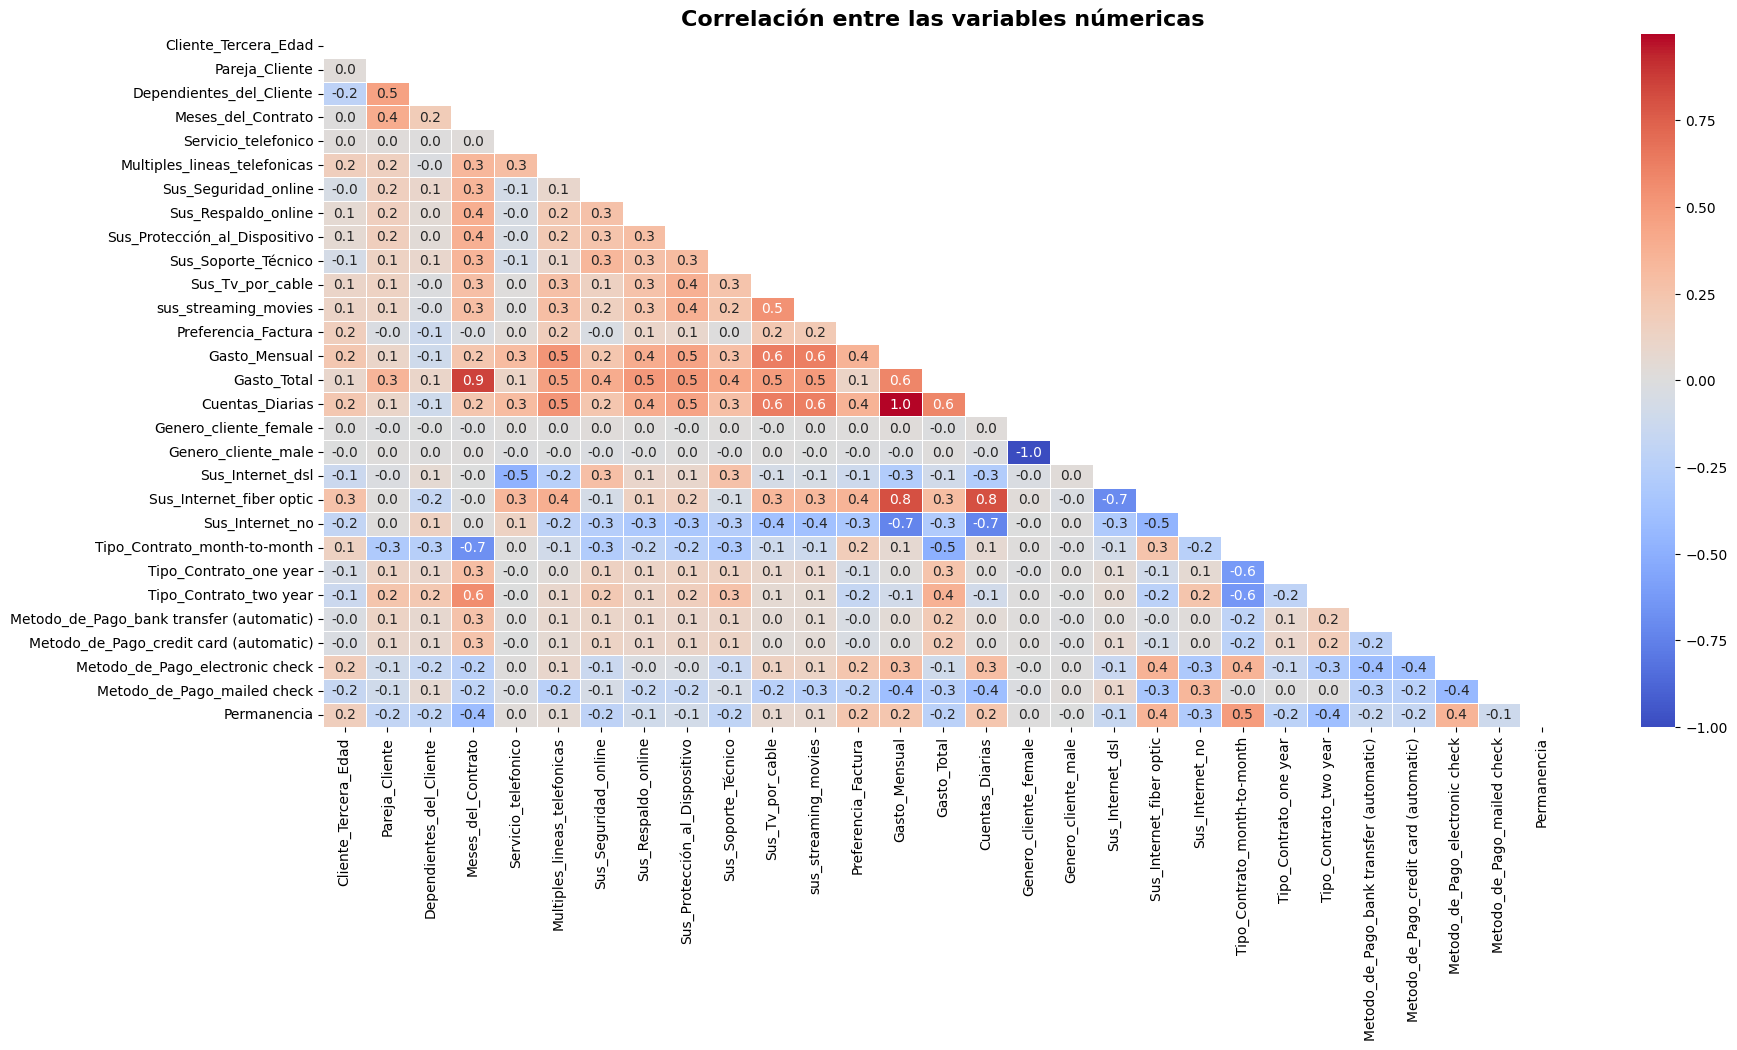

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

corr = datos.corr(numeric_only=True)

mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

fig, ax = plt.subplots(figsize=(20,9))
plt.title('Correlación entre las variables númericas', fontsize=16, fontweight='bold')

sns.heatmap(corr, mask=mascara, cmap='coolwarm', linewidths=0.5, annot=True, fmt='.1f', center=0)

plt.show()

In [34]:
# correlaciones con la variable objetivo 'Permanencia' usando el DataFrame combinado
corr = datos.corr(numeric_only=True)

# Obtener las correlaciones con la variable objetivo 'Permanencia'
correlacion_con_permanencia = corr['Permanencia'].sort_values(ascending=False)

# Mostrar las correlaciones más fuertes (ignorando el signo, es decir, el valor absoluto)
print("Variables con mayor correlación (positiva y negativa) con 'Permanencia' (Churn):\n")

# Excluir la correlación de 'Permanencia' consigo misma y mostrar las top N
# Ordenar por valor absoluto para ver las relaciones más fuertes
top_correlaciones = correlacion_con_permanencia.drop('Permanencia', errors='ignore').abs().sort_values(ascending=False)

print(top_correlaciones.head(15)) # Mostrar las 10 principales

Variables con mayor correlación (positiva y negativa) con 'Permanencia' (Churn):

Tipo_Contrato_month-to-month       0.486504
Meses_del_Contrato                 0.409765
Tipo_Contrato_two year             0.391203
Sus_Internet_fiber optic           0.354772
Metodo_de_Pago_electronic check    0.351898
Sus_Internet_no                    0.291259
Preferencia_Factura                0.240472
Cuentas_Diarias                    0.235733
Gasto_Mensual                      0.235653
Gasto_Total                        0.231256
Tipo_Contrato_one year             0.220251
Sus_Seguridad_online               0.218259
Dependientes_del_Cliente           0.201303
Sus_Soporte_Técnico                0.200606
Pareja_Cliente                     0.182897
Name: Permanencia, dtype: float64


### **Análisis Dirigido**